# Fase 2: implementación

- Pedro Pablo Guzmán Mayen 22111
- Javier Andrés Chen González 22153

Primero, vamos a convertir los mensajes a embeddings para hacer un modelo de red neuronal para la detección de mensajes de SPAM

In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import Counter
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.preprocessing import MinMaxScaler
import warnings
from wordcloud import WordCloud, STOPWORDS
from sklearn.feature_extraction.text import TfidfVectorizer
from google import genai
from dotenv import load_dotenv
import os
from sklearn.preprocessing import normalize
from google.genai import types
import time
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

In [3]:
df = pd.read_csv('../data/dataset_smishing_features.csv')

In [4]:
df.columns

Index(['message', 'label', 'is_spam', 'url_suspicious', 'has_url',
       'impersonation_url', 'has_urgency', 'has_reward', 'has_impersonation',
       'has_threat',
       ...
       'tfidf_usando', 'tfidf_usuario', 'tfidf_vence', 'tfidf_viaje',
       'tfidf_virtual', 'tfidf_válido', 'tfidf_wa', 'tfidf_whatsapp',
       'tfidf_zona', 'embeddings'],
      dtype='object', length=312)

In [ ]:
load_dotenv()

api_key = os.environ.get('GEMINI_API_KEY')

client = genai.Client(api_key=api_key)

df['embeddings']  = None

texts = list(df['message'])

batch_size = 100
all_embeddings = []

for i in range(0, len(texts), batch_size):
    batch = texts[i:i+batch_size]

    result = client.models.embed_content(
        model='gemini-embedding-001',
        contents=batch
    )

    all_embeddings.extend([emb.values for emb in result.embeddings])

    time.sleep(62)

df['embeddings'] = all_embeddings
print('Total embeddings: ' , len(all_embeddings))



/tmp/ipykernel_5057/2911609926.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['embeddings']  = None


Total embeddings:  540


In [ ]:
df['embeddings']

0      [-0.00998275, 0.010763288, -0.0021261303, -0.0...
1      [-0.015649362, -0.019909933, -0.010453295, -0....
2      [0.007600187, -0.009965141, 0.0112251025, -0.0...
3      [-0.02130579, -0.021189542, 0.0018061274, -0.0...
4      [-0.011684055, -0.028987255, -0.0020615507, -0...
                             ...                        
535    [0.010087634, 0.010968973, 0.0075179185, -0.04...
536    [0.0068313526, -0.005296736, -0.005610104, -0....
537    [0.0036117935, -0.0006269517, 0.03621923, -0.0...
538    [-0.007039515, 0.003082279, -0.0071467836, -0....
539    [-0.021652652, 0.0050839176, -0.012516103, -0....
Name: embeddings, Length: 540, dtype: object

In [ ]:
df.to_csv('../data/dataset_smishing_final.csv')

Ya con eso, vamos a usar 2 enfoques para realizar modelos que sean capaces de analizar el contenido de los mensajes:

- Regresión logística con TF-IDF: la regresión logística es un buen calificador binario y TF-IDF nos ayuda a identificar el significado de los mensajes

- Red neuronal con embeddings: los embeddings capturan mejor el significado de los mensajes y con una red neuronal podemos identificar de mejor manera

Empezamos con la regresión logística com TF-IDF

In [ ]:
tfidf_cols = [col for col in df.columns if col.startswith('tfidf_')]

X = df[tfidf_cols]
y = df['is_spam']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

In [ ]:
model = LogisticRegression(max_iter=1000)

param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear']
}

grid = GridSearchCV(
    model,
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=0
)

grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)
print("Best score:", grid.best_score_)

/home/ppguz/Proyecto_SDS/.project/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/ppguz/Proyecto_SDS/.project/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/home/ppguz/Proyecto_SDS/.project/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of pe

Best params: {'C': 10, 'penalty': 'l2', 'solver': 'liblinear'}
Best score: 0.9290247007894067


/home/ppguz/Proyecto_SDS/.project/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/ppguz/Proyecto_SDS/.project/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


In [ ]:

y_pred = grid.predict(X_test)


In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))

Accuracy: 0.9135802469135802
Precision: 0.927536231884058
Recall: 0.8767123287671232
F1: 0.9014084507042254


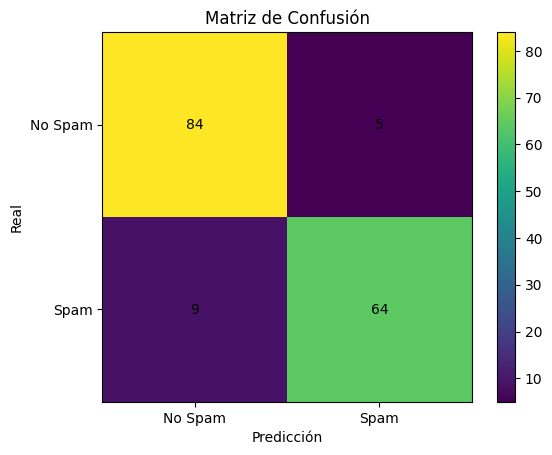

In [ ]:
cm = confusion_matrix(y_test, y_pred)


plt.imshow(cm)
plt.title("Matriz de Confusión")
plt.colorbar()

plt.xticks([0,1], ['No Spam', 'Spam'])
plt.yticks([0,1], ['No Spam', 'Spam'])

plt.xlabel('Predicción')
plt.ylabel('Real')

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha='center', va='center')

plt.show()

---
## Modelos con Características



In [5]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import roc_curve, auc, RocCurveDisplay
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np

df_feat = pd.read_csv('../data/dataset_smishing_features.csv')

exclude_cols = ['message', 'label', 'is_spam', 'embeddings']
tfidf_cols = [col for col in df_feat.columns if col.startswith('tfidf_')]
feature_cols = [col for col in df_feat.columns if col not in exclude_cols and col not in tfidf_cols]

print('Características engineered utilizadas:')
print(feature_cols)
print(f'\nTotal features: {len(feature_cols)}')

Características engineered utilizadas:
['url_suspicious', 'has_url', 'impersonation_url', 'has_urgency', 'has_reward', 'has_impersonation', 'has_threat', 'has_cta']

Total features: 8


In [6]:
X_feat = df_feat[feature_cols]
y_feat = df_feat['is_spam']

X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(
    X_feat, y_feat, test_size=0.3, random_state=42, stratify=y_feat
)

print(f'Train size: {X_train_f.shape[0]} | Test size: {X_test_f.shape[0]}')
print(f'Proporción spam en test: {y_test_f.mean():.2%}')

Train size: 378 | Test size: 162
Proporción spam en test: 45.06%


### Modelo 1: Random Forest



In [7]:
param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'class_weight': ['balanced', None]
}

rf = RandomForestClassifier(random_state=42)
# Usamos recall como scoring para priorizar detección de spam (reducir falsos negativos)
grid_rf = GridSearchCV(rf, param_grid_rf, cv=5, scoring='recall', n_jobs=-1, verbose=0)
grid_rf.fit(X_train_f, y_train_f)

print('Mejores hiperparámetros RF:', grid_rf.best_params_)
print('Mejor Recall en CV:', round(grid_rf.best_score_, 4))

Mejores hiperparámetros RF: {'class_weight': 'balanced', 'max_depth': None, 'min_samples_split': 2, 'n_estimators': 300}
Mejor Recall en CV: 0.8235


In [8]:
y_pred_rf = grid_rf.predict(X_test_f)
y_prob_rf = grid_rf.predict_proba(X_test_f)[:, 1]

print('=== Random Forest - Métricas ===')
print(f'Accuracy : {accuracy_score(y_test_f, y_pred_rf):.4f}')
print(f'Precision: {precision_score(y_test_f, y_pred_rf):.4f}')
print(f'Recall   : {recall_score(y_test_f, y_pred_rf):.4f}')
print(f'F1 Score : {f1_score(y_test_f, y_pred_rf):.4f}')
print()
print(classification_report(y_test_f, y_pred_rf, target_names=['No Spam', 'Spam']))

=== Random Forest - Métricas ===
Accuracy : 0.8210
Precision: 0.8143
Recall   : 0.7808
F1 Score : 0.7972

              precision    recall  f1-score   support

     No Spam       0.83      0.85      0.84        89
        Spam       0.81      0.78      0.80        73

    accuracy                           0.82       162
   macro avg       0.82      0.82      0.82       162
weighted avg       0.82      0.82      0.82       162



In [9]:
# Ajuste de umbral para mejorar Recall en Spam
threshold = 0.4
y_pred_rf_adj = (y_prob_rf >= threshold).astype(int)

print(f'=== Random Forest con umbral {threshold} ===')
print(f'Accuracy : {accuracy_score(y_test_f, y_pred_rf_adj):.4f}')
print(f'Precision: {precision_score(y_test_f, y_pred_rf_adj):.4f}')
print(f'Recall   : {recall_score(y_test_f, y_pred_rf_adj):.4f}')
print(f'F1 Score : {f1_score(y_test_f, y_pred_rf_adj):.4f}')
print()
print('Comparación Recall Spam:')
print(f'  Umbral 0.5: {recall_score(y_test_f, y_pred_rf):.4f}')
print(f'  Umbral 0.4: {recall_score(y_test_f, y_pred_rf_adj):.4f}')

=== Random Forest con umbral 0.4 ===
Accuracy : 0.8210
Precision: 0.7973
Recall   : 0.8082
F1 Score : 0.8027

Comparación Recall Spam:
  Umbral 0.5: 0.7808
  Umbral 0.4: 0.8082


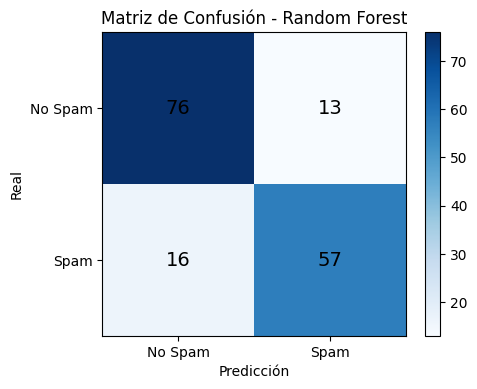

In [10]:
# Matriz de Confusión - Random Forest
cm_rf = confusion_matrix(y_test_f, y_pred_rf)
plt.figure(figsize=(5, 4))
plt.imshow(cm_rf, cmap='Blues')
plt.title('Matriz de Confusión - Random Forest')
plt.colorbar()
plt.xticks([0,1], ['No Spam', 'Spam'])
plt.yticks([0,1], ['No Spam', 'Spam'])
plt.xlabel('Predicción')
plt.ylabel('Real')
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm_rf[i, j], ha='center', va='center', fontsize=14)
plt.tight_layout()
plt.show()

### Modelo 2: Gradient Boosting


In [11]:
from sklearn.utils.class_weight import compute_sample_weight

param_grid_gb = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth': [3, 5]
}

sample_weights = compute_sample_weight(class_weight='balanced', y=y_train_f)

gb = GradientBoostingClassifier(random_state=42)
grid_gb = GridSearchCV(gb, param_grid_gb, cv=5, scoring='recall', n_jobs=-1, verbose=0)
grid_gb.fit(X_train_f, y_train_f, sample_weight=sample_weights)

print('Mejores hiperparámetros GB:', grid_gb.best_params_)
print('Mejor Recall en CV:', round(grid_gb.best_score_, 4))

Mejores hiperparámetros GB: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}
Mejor Recall en CV: 0.8235


In [12]:
y_pred_gb = grid_gb.predict(X_test_f)
y_prob_gb = grid_gb.predict_proba(X_test_f)[:, 1]

print('=== Gradient Boosting - Métricas ===')
print(f'Accuracy : {accuracy_score(y_test_f, y_pred_gb):.4f}')
print(f'Precision: {precision_score(y_test_f, y_pred_gb):.4f}')
print(f'Recall   : {recall_score(y_test_f, y_pred_gb):.4f}')
print(f'F1 Score : {f1_score(y_test_f, y_pred_gb):.4f}')
print()
print(classification_report(y_test_f, y_pred_gb, target_names=['No Spam', 'Spam']))

=== Gradient Boosting - Métricas ===
Accuracy : 0.8148
Precision: 0.8028
Recall   : 0.7808
F1 Score : 0.7917

              precision    recall  f1-score   support

     No Spam       0.82      0.84      0.83        89
        Spam       0.80      0.78      0.79        73

    accuracy                           0.81       162
   macro avg       0.81      0.81      0.81       162
weighted avg       0.81      0.81      0.81       162



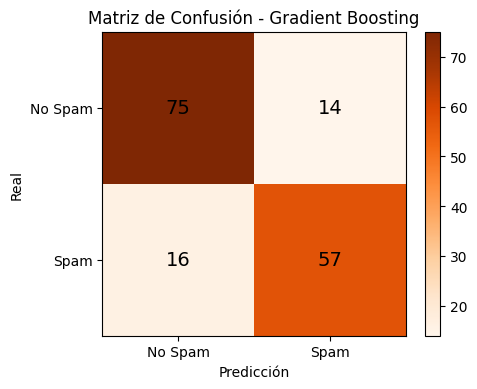

In [13]:
# Matriz de Confusión - Gradient Boosting
cm_gb = confusion_matrix(y_test_f, y_pred_gb)
plt.figure(figsize=(5, 4))
plt.imshow(cm_gb, cmap='Oranges')
plt.title('Matriz de Confusión - Gradient Boosting')
plt.colorbar()
plt.xticks([0,1], ['No Spam', 'Spam'])
plt.yticks([0,1], ['No Spam', 'Spam'])
plt.xlabel('Predicción')
plt.ylabel('Real')
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm_gb[i, j], ha='center', va='center', fontsize=14)
plt.tight_layout()
plt.show()

### Modelo 3: SVM con Kernel RBF



In [14]:
param_grid_svm = {
    'svm__C': [0.1, 1, 10],
    'svm__gamma': ['scale', 'auto'],
    'svm__class_weight': ['balanced', None]
}

svm_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='rbf', probability=True, random_state=42))
])

grid_svm = GridSearchCV(svm_pipeline, param_grid_svm, cv=5, scoring='recall', n_jobs=-1, verbose=0)
grid_svm.fit(X_train_f, y_train_f)

print('Mejores hiperparámetros SVM:', grid_svm.best_params_)
print('Mejor Recall en CV:', round(grid_svm.best_score_, 4))

Mejores hiperparámetros SVM: {'svm__C': 0.1, 'svm__class_weight': 'balanced', 'svm__gamma': 'scale'}
Mejor Recall en CV: 0.8706


In [15]:
y_pred_svm = grid_svm.predict(X_test_f)
y_prob_svm = grid_svm.predict_proba(X_test_f)[:, 1]

print('=== SVM RBF - Métricas ===')
print(f'Accuracy : {accuracy_score(y_test_f, y_pred_svm):.4f}')
print(f'Precision: {precision_score(y_test_f, y_pred_svm):.4f}')
print(f'Recall   : {recall_score(y_test_f, y_pred_svm):.4f}')
print(f'F1 Score : {f1_score(y_test_f, y_pred_svm):.4f}')
print()
print(classification_report(y_test_f, y_pred_svm, target_names=['No Spam', 'Spam']))

=== SVM RBF - Métricas ===
Accuracy : 0.7840
Precision: 0.7436
Recall   : 0.7945
F1 Score : 0.7682

              precision    recall  f1-score   support

     No Spam       0.82      0.78      0.80        89
        Spam       0.74      0.79      0.77        73

    accuracy                           0.78       162
   macro avg       0.78      0.78      0.78       162
weighted avg       0.79      0.78      0.78       162



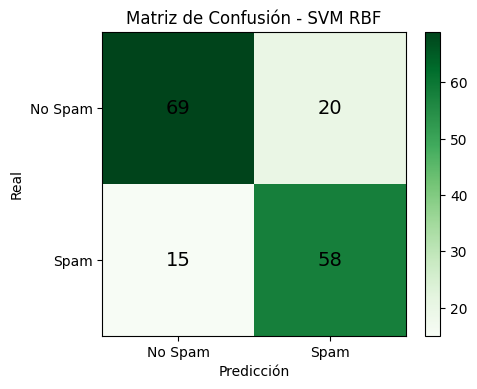

In [16]:
# Matriz de Confusión - SVM
cm_svm = confusion_matrix(y_test_f, y_pred_svm)
plt.figure(figsize=(5, 4))
plt.imshow(cm_svm, cmap='Greens')
plt.title('Matriz de Confusión - SVM RBF')
plt.colorbar()
plt.xticks([0,1], ['No Spam', 'Spam'])
plt.yticks([0,1], ['No Spam', 'Spam'])
plt.xlabel('Predicción')
plt.ylabel('Real')
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm_svm[i, j], ha='center', va='center', fontsize=14)
plt.tight_layout()
plt.show()

### Curvas ROC - Comparación de modelos

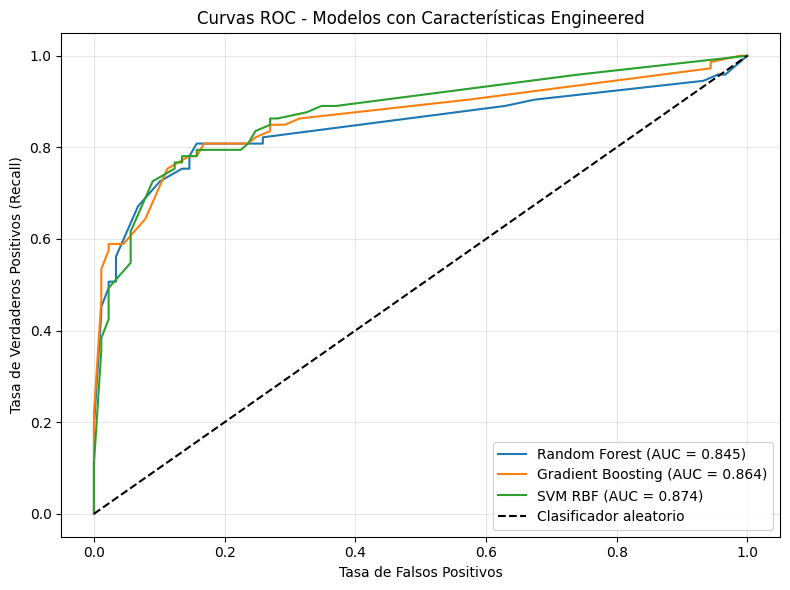

In [17]:
plt.figure(figsize=(8, 6))

models_roc = [
    ('Random Forest', y_prob_rf),
    ('Gradient Boosting', y_prob_gb),
    ('SVM RBF', y_prob_svm),
]

for name, y_prob in models_roc:
    fpr, tpr, _ = roc_curve(y_test_f, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Clasificador aleatorio')
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos (Recall)')
plt.title('Curvas ROC - Modelos con Características Engineered')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Importancia de características - Random Forest



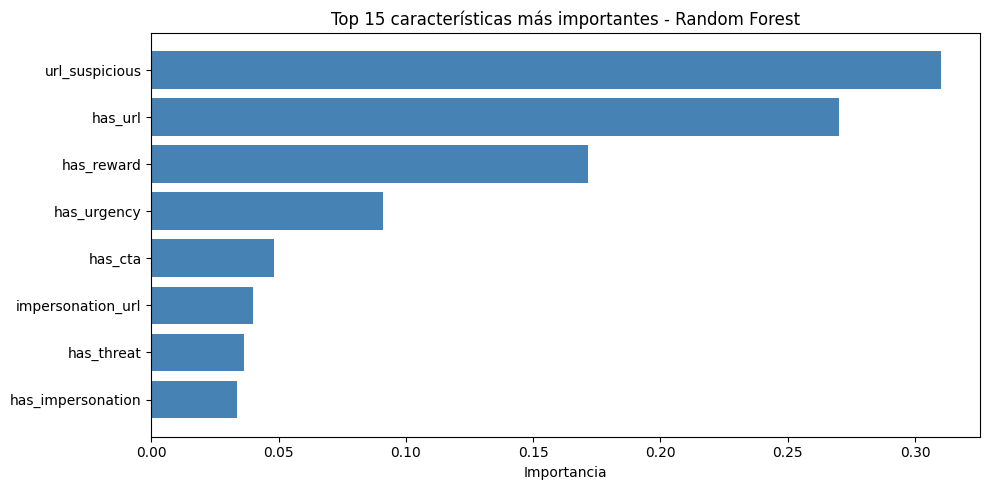

In [18]:
best_rf = grid_rf.best_estimator_
importances = best_rf.feature_importances_
feat_importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': importances
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 5))
plt.barh(feat_importance_df['feature'][:15][::-1],
         feat_importance_df['importance'][:15][::-1],
         color='steelblue')
plt.xlabel('Importancia')
plt.title('Top 15 características más importantes - Random Forest')
plt.tight_layout()
plt.show()

### Importancia de características

Antes de analizar las métricas, la gráfica de importancia del Random Forest revela qué señales del mensaje son más determinantes para la detección de smishing:

- **`url_suspicious` (0.31) y `has_url` (0.27)** son por lejos las características más importantes, acumulando casi el 58% del poder predictivo del modelo. Esto tiene sentido en el contexto de smishing: la mayoría de ataques dirigen a la víctima a un enlace malicioso para robar credenciales o instalar malware. La presencia de una URL, y especialmente una URL con características sospechosas (dominios extraños, acortadores, etc.), es la señal más clara de un mensaje malicioso.

- **`has_reward` (0.17)** ocupa el tercer lugar. Los mensajes de smishing frecuentemente prometen premios, descuentos o beneficios falsos para motivar al usuario a hacer clic. Frases como "ganaste un premio" o "reclama tu bono" son indicadores fuertes.

- **`has_urgency` (0.09)** contribuye de forma moderada. El lenguaje de urgencia ("tu cuenta será bloqueada", "responde en 24 horas") es una táctica psicológica común en phishing para presionar al usuario a actuar sin reflexionar.

- Las características restantes (`has_cta`, `impersonation_url`, `has_threat`, `has_impersonation`) tienen importancias menores pero complementarias, capturando tácticas secundarias de los atacantes.

Esta jerarquía confirma que los vectores de ataque principales en smishing son los enlaces maliciosos y las promesas de recompensa, mientras que amenazas y suplantación de identidad son tácticas de apoyo.

### Análisis por modelo

**Random Forest** — Accuracy: 0.8210 | Precision: 0.8143 | Recall: 0.7808 | F1: 0.7972

La matriz de confusión muestra 16 falsos negativos (spam no detectado) sobre 73 mensajes spam reales. Es el modelo con mayor Precision (0.81), lo que significa que cuando predice spam, acierta con alta confianza. Sin embargo, su Recall de 0.78 indica que aproximadamente 1 de cada 5 mensajes maliciosos no es detectado. En un escenario de seguridad real esto representaría un riesgo considerable. El AUC de 0.845 refleja una buena capacidad discriminativa general, aunque por debajo de los otros dos modelos.

---

**Gradient Boosting** — Accuracy: 0.8148 | Precision: 0.8028 | Recall: 0.7808 | F1: 0.7917

Presenta resultados casi idénticos al Random Forest (también 16 falsos negativos), con una ligera caída en Precision. Esto sugiere que ambos modelos de ensemble basados en árboles llegan al mismo techo de información con estas features. Su AUC de 0.864 es mejor que el del RF, lo que indica que el modelo tiene mejor capacidad de separación en distintos umbrales aunque con el umbral por defecto (0.5) su rendimiento sea similar. Podría beneficiarse más de un ajuste de umbral.

---

**SVM RBF** — Accuracy: 0.7840 | Precision: 0.7436 | Recall: 0.7945 | F1: 0.7682

El SVM muestra un comportamiento distinto a los modelos de árboles: sacrifica Precision (0.74, la más baja) para ganar Recall (0.7945, el más alto entre los tres con umbral 0.5). Tiene 15 falsos negativos (uno menos que RF y GB) pero 20 falsos positivos, lo que significa que marca más mensajes legítimos como spam. En el contexto de smishing, **este trade-off es preferible**: es mejor molestar ocasionalmente al usuario con una alerta innecesaria que dejar pasar un mensaje malicioso. El AUC de 0.874 es el más alto de los tres, confirmando que tiene la mejor capacidad discriminativa general.

### Curvas ROC y comparación general

Las curvas ROC confirman el ranking de los modelos en términos de capacidad discriminativa:

| Modelo | Accuracy | Precision | Recall | F1 | AUC |
|---|---|---|---|---|---|
| Random Forest | 0.8210 | 0.8143 | 0.7808 | 0.7972 | 0.845 |
| Gradient Boosting | 0.8148 | 0.8028 | 0.7808 | 0.7917 | 0.864 |
| SVM RBF | 0.7840 | 0.7436 | 0.7945 | 0.7682 | **0.874** |

Los tres modelos superan ampliamente al clasificador aleatorio (AUC = 0.5), con AUCs entre 0.845 y 0.874. Esto indica que las características engineered tienen poder predictivo real para distinguir smishing de mensajes legítimos.

El **SVM RBF es el modelo más recomendable** para este problema por su AUC más alto y su mayor Recall, que prioriza no dejar pasar mensajes maliciosos. El ajuste de umbral a 0.4 en el Random Forest permite mejorar su Recall a 0.8082 con un costo mínimo en Precision, acercándolo al rendimiento del SVM.

Una limitación importante de estos modelos es que dependen completamente de las características extraídas manualmente. Si un mensaje de smishing no contiene URLs, no usa lenguaje de urgencia explícito ni promesas de recompensa, los modelos tendrían dificultades para detectarlo. Esto contrasta con los modelos de TF-IDF y embeddings , que analizan el contenido completo del mensaje y pueden capturar patrones más sutiles.